In [32]:
import yfinance as yf
import pandas as pd
import ta


In [33]:
# ticker에 야후 파이낸스의 티커 코 입력 시 기간별 시가, 고가, 종가, 저가, 거래량 피쳐 출력


ticker = "TSLA"
df = yf.download(ticker, start="2021-05-19", end="2025-06-25", interval="1d")

print(df.head())
"""
open : 시가
high : 고가
low : 저가
close : 종가
adj close : 수정 종가(주식 분할, 배당 반영)
volume : 거래량



"""

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_3063/1917857184.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2021-05-19", end="2025-06-25", interval="1d")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2021-05-19  187.820007  188.736664  182.326660  184.183334  118735200
2021-05-20  195.593338  196.283340  190.356674  191.666672   92463300
2021-05-21  193.626663  198.893326  193.333328  198.703339   78091800
2021-05-24  202.146667  204.826660  191.216660  193.866669  103674300
2021-05-25  201.563339  204.663330  198.570007  202.436661   84017700


'\nopen : 시가\nhigh : 고가\nlow : 저가\nclose : 종가\nadj close : 수정 종가(주식 분할, 배당 반영)\nvolume : 거래량\n\n\n\n'

In [34]:
# 2. 다중컬럼 구조인 경우 첫 번째 레벨 제거 (있을 경우만)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(0)
    df.columns.name = None


In [35]:
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']



In [36]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2021-05-19,187.820007,188.736664,182.326660,184.183334,118735200
2021-05-20,195.593338,196.283340,190.356674,191.666672,92463300
2021-05-21,193.626663,198.893326,193.333328,198.703339,78091800
2021-05-24,202.146667,204.826660,191.216660,193.866669,103674300
2021-05-25,201.563339,204.663330,198.570007,202.436661,84017700
...,...,...,...,...,...
2025-06-17,316.350006,327.260010,314.739990,326.089996,88282700
2025-06-18,322.049988,329.320007,315.450012,317.309998,95137700
2025-06-20,322.160004,332.359985,317.779999,327.950012,108688000


In [37]:
# 기술적 지표 추가
df_ta = ta.add_all_ta_features(
    df,
    open="Open",
    high="High",
    low="Low",
    close="Close",
    volume="Volume",
    fillna=True  # NaN 값 보완
)

# 결과 확인
print(df_ta.shape)
print(df_ta.columns[-10:])  # 마지막 10개 지표 확인

(1029, 91)
Index(['momentum_ppo', 'momentum_ppo_signal', 'momentum_ppo_hist',
       'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist',
       'momentum_kama', 'others_dr', 'others_dlr', 'others_cr'],
      dtype='object')


/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [38]:
df_ta

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-19,187.820007,188.736664,182.326660,184.183334,118735200,-4.995128e+07,118735200,-0.420695,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.183334,0.000000,0.000000,0.000000
2021-05-20,195.593338,196.283340,190.356674,191.666672,92463300,-1.015394e+08,211198500,-0.480777,6.919341e+08,49.921346,...,0.323140,0.064628,0.258512,-1.794486,-0.358897,-1.435588,186.393116,4.062983,3.982613,4.062983
2021-05-21,193.626663,198.893326,193.333328,198.703339,78091800,-2.878448e+07,289290300,-0.099500,6.715872e+08,19.887941,...,0.871601,0.226023,0.645579,-4.266320,-1.140382,-3.125938,189.067218,3.671304,3.605517,7.883452
2021-05-24,202.146667,204.826660,191.216660,193.866669,103674300,-9.208584e+07,185616000,-0.234336,5.040121e+08,25.051928,...,1.081603,0.397139,0.684464,-4.356615,-1.783628,-2.572987,190.006883,-2.434116,-2.464230,5.257443
2021-05-25,201.563339,204.663330,198.570007,202.436661,84017700,-6.947294e+07,269633700,-0.145651,5.348720e+08,26.072541,...,1.592655,0.636242,0.956413,-5.852593,-2.597421,-3.255172,192.553418,4.420560,4.325640,9.910412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17,316.350006,327.260010,314.739990,326.089996,88282700,3.147111e+08,1230848900,0.112608,-1.839639e+08,-116.715627,...,1.068839,2.136559,-1.067719,-1.154293,2.727474,-3.881767,327.462655,-1.569625,-1.582074,77.046418
2025-06-18,322.049988,329.320007,315.450012,317.309998,95137700,2.450896e+08,1135711200,0.088491,-2.770132e+08,20.191868,...,0.794976,1.868242,-1.073266,-2.646742,1.652631,-4.299373,327.170777,-2.692508,-2.729420,72.279429
2025-06-20,322.160004,332.359985,317.779999,327.950012,108688000,2.880284e+08,1244399200,0.079805,-7.223392e+07,36.017781,...,0.833305,1.661255,-0.827950,-2.870439,0.748017,-3.618456,327.176652,3.353192,3.298199,78.056290


In [39]:
# 전일 대비 주가 상승률 (%) 계산
df_ta['pct_change_close'] = (df_ta['Close'] - df_ta['Close'].shift(1)) / df_ta['Close'].shift(1) * 100

# 혹은 더 간결하게 (판다스 기본 함수 활용)
# df_ta['pct_change_close'] = df_ta['Close'].pct_change() * 100

# 결측치 제거 (첫날은 NaN이므로)
df_ta = df_ta.dropna(subset=['pct_change_close'])


In [40]:
df_ta

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,pct_change_close
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-20,195.593338,196.283340,190.356674,191.666672,92463300,-1.015394e+08,211198500,-0.480777,6.919341e+08,49.921346,...,0.064628,0.258512,-1.794486,-0.358897,-1.435588,186.393116,4.062983,3.982613,4.062983,4.062983
2021-05-21,193.626663,198.893326,193.333328,198.703339,78091800,-2.878448e+07,289290300,-0.099500,6.715872e+08,19.887941,...,0.226023,0.645579,-4.266320,-1.140382,-3.125938,189.067218,3.671304,3.605517,7.883452,3.671304
2021-05-24,202.146667,204.826660,191.216660,193.866669,103674300,-9.208584e+07,185616000,-0.234336,5.040121e+08,25.051928,...,0.397139,0.684464,-4.356615,-1.783628,-2.572987,190.006883,-2.434116,-2.464230,5.257443,-2.434116
2021-05-25,201.563339,204.663330,198.570007,202.436661,84017700,-6.947294e+07,269633700,-0.145651,5.348720e+08,26.072541,...,0.636242,0.956413,-5.852593,-2.597421,-3.255172,192.553418,4.420560,4.325640,9.910412,4.420560
2021-05-26,206.376663,208.723328,200.500000,202.520004,85917900,-1.131806e+08,355551600,-0.201067,4.594846e+08,28.665535,...,0.903428,1.068744,-6.870025,-3.451942,-3.418083,194.452905,0.041170,0.041162,9.955662,0.041170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17,316.350006,327.260010,314.739990,326.089996,88282700,3.147111e+08,1230848900,0.112608,-1.839639e+08,-116.715627,...,2.136559,-1.067719,-1.154293,2.727474,-3.881767,327.462655,-1.569625,-1.582074,77.046418,-1.569625
2025-06-18,322.049988,329.320007,315.450012,317.309998,95137700,2.450896e+08,1135711200,0.088491,-2.770132e+08,20.191868,...,1.868242,-1.073266,-2.646742,1.652631,-4.299373,327.170777,-2.692508,-2.729420,72.279429,-2.692508
2025-06-20,322.160004,332.359985,317.779999,327.950012,108688000,2.880284e+08,1244399200,0.079805,-7.223392e+07,36.017781,...,1.661255,-0.827950,-2.870439,0.748017,-3.618456,327.176652,3.353192,3.298199,78.056290,3.353192


In [41]:
print(df_ta.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Volume', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_

In [42]:
# 향후 5일 내 최대 종가 계산
df_ta['future_max_close'] = df_ta['Close'].shift(-1).rolling(window=5).max()

# 미래 수익률 계산 (현재 종가 대비)
df_ta['future_return'] = (df_ta['future_max_close'] - df_ta['Close']) / df_ta['Close'] * 100

# 타깃 라벨 정의: 5일 내 10% 이상 상승 → 1, 아니면 0
df_ta['target_label'] = (df_ta['future_return'] >= 10).astype(int)

# 필요 없는 중간 컬럼 제거
df_ta.drop(columns=['future_max_close', 'future_return'], inplace=True)

# NaN 제거 (지표 및 수익률 계산 후)
df_ta.dropna(inplace=True)

# 결과 확인
print(df_ta['target_label'].value_counts())


target_label
0    924
1    104
Name: count, dtype: int64


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_3063/3113793119.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ta['future_max_close'] = df_ta['Close'].shift(-1).rolling(window=5).max()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_3063/3113793119.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ta['future_return'] = (df_ta['future_max_close'] - df_ta['Close']) / df_ta['Close'] * 100
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_3063/3113793119.py:8: Setting

In [43]:
# 타깃 설정
y = df_ta['target_label']

# 피처: 종가(Close), 타깃 제거
X = df_ta.drop(columns=['target_label', 'Close'])


In [46]:
from sklearn.model_selection import train_test_split

# 시간 순서 유지: shuffle=False
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 모델 정의 및 학습
model = XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))


[[177   2]
 [ 12  15]]
              precision    recall  f1-score   support

           0     0.9365    0.9888    0.9620       179
           1     0.8824    0.5556    0.6818        27

    accuracy                         0.9320       206
   macro avg     0.9094    0.7722    0.8219       206
weighted avg     0.9294    0.9320    0.9252       206



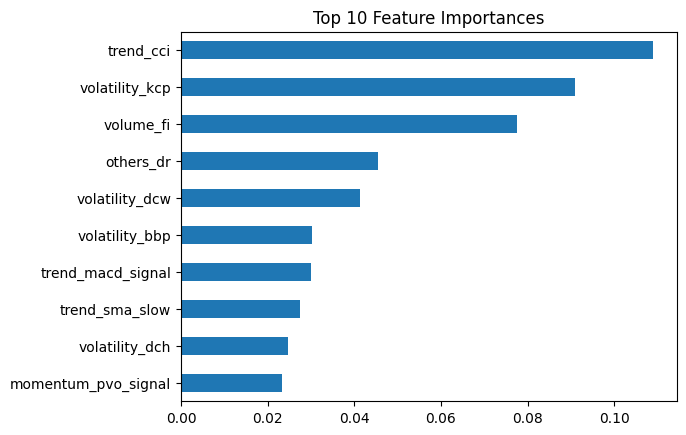

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
"""
| 순위  | 변수명                   | 설명                                                                                                |
| --- | --------------------- | ------------------------------------------------------------------------------------------------- |
| 1️⃣ | `trend_cci`           | **CCI (Commodity Channel Index)**<br>과매수/과매도 판단 지표. 가격이 평균보다 얼마나 벗어나 있는지를 나타냄. 보통 ±100 기준으로 판단.   |
| 2️⃣ | `volatility_kcp`      | \*\*KCP (Keltner Channel Percent)\*\*로 추정됨<br>가격이 Keltner 채널 상/하단에서 얼마나 떨어졌는지 비율로 나타냄. 변동성 측정 지표. |
| 3️⃣ | `volume_fi`           | **Force Index (FI)**<br>거래량과 가격 변화율을 곱한 값. 매수·매도 강도의 에너지를 나타내는 지표.                                |
| 4️⃣ | `others_dr`           | **Daily Return (dr)** 추정<br>당일 수익률(종가 기준). 주가 변동 방향과 강도를 단순히 반영함.                                 |
| 5️⃣ | `volatility_dcw`      | **Donchian Channel Width**<br>최근 고가와 저가의 차이로, 시장의 전반적인 변동성을 나타냄.                                  |
| 6️⃣ | `volatility_bbp`      | **Bollinger Band Percent (BBP)**<br>현재 가격이 볼린저 밴드 내 어디쯤 위치하는지를 나타냄 (0: 하단, 1: 상단). 과매수/과매도 감지용.   |
| 7️⃣ | `trend_macd_signal`   | **MACD Signal Line**<br>MACD 지표의 신호선. 매수/매도 시점을 포착할 때 사용됨.                                        |
| 8️⃣ | `trend_sma_slow`      | **Slow Simple Moving Average**<br>장기 단순 이동 평균선. 추세의 방향성과 장기 흐름 확인에 사용됨.                           |
| 9️⃣ | `volatility_dch`      | **Donchian Channel High**<br>최근 기간 내 최고가. 추세 상단을 감지하거나 돌파 판단 기준으로 활용됨.                            |
| 🔟  | `momentum_pvo_signal` | **Percentage Volume Oscillator (PVO) Signal**<br>거래량 기반 오실레이터의 신호선. 거래량의 변동 추세를 측정함.              |

"""

In [53]:
import joblib

In [54]:
# 학습 완료 후 모델 저장
joblib.dump(model, 'xgb_model_tesla.pkl')
print("모델 저장 완료: xgb_model_tesla.pkl")

모델 저장 완료: xgb_model_tesla.pkl


In [55]:
# 학습에 사용된 컬럼 목록 저장
feature_columns = X.columns.tolist()
import joblib
joblib.dump(feature_columns, 'xgb_feature_columns.pkl')


['xgb_feature_columns.pkl']